<a href="https://colab.research.google.com/github/thesixthman0-sports/scout-analytics-football/blob/main/scout_analytics_football_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding Similar Players: Serie A 2015/16

Given a reference player (Mohamed Salah), find the Serie A players whose on-pitch behaviour
is most similar, using StatsBomb Open Data.

Data: StatsBomb Open Data (https://github.com/statsbomb/open-data)

## 1. Setup and match list

In [1]:
!pip install statsbombpy

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
from google.colab import drive

warnings.filterwarnings("ignore")
drive.mount("/content/drive")
folder = "/content/drive/MyDrive/football_portfolio"
os.makedirs(folder, exist_ok=True)

comps = sb.competitions()
row = comps[(comps.competition_name == "Serie A") & (comps.season_name == "2015/2016")].iloc[0]
matches = sb.matches(competition_id=row.competition_id, season_id=row.season_id)
print(len(matches), "матчей")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.0 MB/s eta 0:00:00
Mounted at /content/drive
380 матчей


## 2. Load all match events

In [2]:
path = f"{folder}/seriea_1516_events.pkl"

if os.path.exists(path):
    events = pd.read_pickle(path)
else:
    keep = [
        "match_id", "team", "player", "player_id", "position", "type",
        "period", "minute", "second", "location", "under_pressure",
        "pass_end_location", "pass_outcome", "pass_length", "pass_cross",
        "pass_through_ball", "pass_shot_assist", "pass_goal_assist",
        "shot_outcome", "shot_statsbomb_xg", "dribble_outcome",
        "duel_type", "duel_outcome", "interception_outcome",
        "carry_end_location", "tactics", "substitution_replacement",
    ]
    frames = []
    for i, mid in enumerate(matches.match_id):
        try:
            e = sb.events(match_id=mid)
        except Exception as ex:
            print("ошибка в матче", mid, ex)
            continue
        frames.append(e[[c for c in keep if c in e.columns]])
        if (i + 1) % 20 == 0:
            print(i + 1, "из", len(matches))
    events = pd.concat(frames, ignore_index=True)
    events.to_pickle(path)

print("готово:", events.shape)

готово: (1353739, 27)


## 3. Minutes played

In [3]:
match_end = events.groupby("match_id")["minute"].max()
stint = {}

for _, r in events[events.type == "Starting XI"].iterrows():
    for p in r.tactics["lineup"]:
        stint[(r.match_id, p["player"]["name"])] = [0, match_end[r.match_id], r.team]

for _, r in events[events.type == "Substitution"].iterrows():
    mid = r.match_id
    if (mid, r.player) in stint:
        stint[(mid, r.player)][1] = r.minute
    stint[(mid, r.substitution_replacement)] = [r.minute, match_end[mid], r.team]

minutes = pd.DataFrame(
    [(m, p, t, s, e) for (m, p), (s, e, t) in stint.items()],
    columns=["match_id", "player", "team", "start", "end"],
)
minutes["mins"] = minutes["end"] - minutes["start"]
minutes.to_pickle(f"{folder}/seriea_1516_minutes.pkl")
print(minutes.shape)

(10598, 6)


## 4. Per-90 metrics

In [4]:
events = pd.read_pickle(f"{folder}/seriea_1516_events.pkl")
minutes = pd.read_pickle(f"{folder}/seriea_1516_minutes.pkl")

def split_xy(col, prefix):
    events[prefix + "_x"] = np.nan
    events[prefix + "_y"] = np.nan
    s = events[col]
    ok = s.notna()
    arr = pd.DataFrame(s[ok].tolist(), index=s[ok].index)
    events.loc[ok, prefix + "_x"] = arr[0]
    events.loc[ok, prefix + "_y"] = arr[1]

split_xy("location", "s")
split_xy("pass_end_location", "pe")
split_xy("carry_end_location", "ce")

def dgoal(x, y):
    return np.sqrt((120 - x) ** 2 + (40 - y) ** 2)

events["pass_prog"] = dgoal(events.s_x, events.s_y) - dgoal(events.pe_x, events.pe_y)
events["carry_prog"] = dgoal(events.s_x, events.s_y) - dgoal(events.ce_x, events.ce_y)

t = events.type
done = events.pass_outcome.isna()
won_outcomes = ["Won", "Success In Play", "Success Out"]

flags = pd.DataFrame({
    "passes": t == "Pass",
    "passes_done": (t == "Pass") & done,
    "prog_passes": (t == "Pass") & done & (events.pass_prog >= 10),
    "key_passes": (events.pass_shot_assist == True) | (events.pass_goal_assist == True),
    "assists": events.pass_goal_assist == True,
    "crosses": events.pass_cross == True,
    "through_balls": events.pass_through_ball == True,
    "shots": t == "Shot",
    "goals": (t == "Shot") & (events.shot_outcome == "Goal"),
    "dribbles": t == "Dribble",
    "dribbles_won": (t == "Dribble") & (events.dribble_outcome == "Complete"),
    "carries": t == "Carry",
    "prog_carries": (t == "Carry") & (events.carry_prog >= 10),
    "receipts": t == "Ball Receipt*",
    "tackles": (t == "Duel") & (events.duel_type == "Tackle"),
    "tackles_won": (t == "Duel") & (events.duel_type == "Tackle") & events.duel_outcome.isin(won_outcomes),
    "interceptions": t == "Interception",
    "recoveries": t == "Ball Recovery",
    "pressures": t == "Pressure",
    "clearances": t == "Clearance",
    "blocks": t == "Block",
    "fouls": t == "Foul Committed",
    "fouls_won": t == "Foul Won",
    "dispossessed": t == "Dispossessed",
})
flags["xg"] = events.shot_statsbomb_xg.fillna(0)
flags["player"] = events.player

stats = flags[flags.player.notna()].groupby("player").sum()

pos = (events.dropna(subset=["player", "position"])
       .groupby("player")["position"].agg(lambda s: s.mode().iat[0]))
avg = events.dropna(subset=["player", "s_x"]).groupby("player")[["s_x", "s_y"]].mean()

pm = minutes.groupby("player")["mins"].sum()
pt = minutes.groupby(["player", "team"])["mins"].sum().reset_index().sort_values("mins", ascending=False)
team = pt.drop_duplicates("player").set_index("player")["team"]

def grp(p):
    if p == "Goalkeeper": return "GK"
    if "Back" in p: return "DEF"
    if "Midfield" in p: return "MID"
    return "ATT"

players = (stats.join(pm.rename("mins")).join(pos.rename("position"))
           .join(avg).join(team.rename("team")))
players["group"] = players.position.map(grp)
players = players[(players.mins >= 900) & (players.group != "GK")]

count_cols = [c for c in flags.columns if c != "player"]
per90 = players.copy()
for c in count_cols:
    per90[c] = players[c] / players.mins * 90
per90["pass_pct"] = players.passes_done / players.passes

per90.to_pickle(f"{folder}/seriea_1516_per90.pkl")
print(per90.shape)
print(players.group.value_counts())

(320, 32)
group
DEF    133
MID    106
ATT     81
Name: count, dtype: int64


## 5. Similarity search and radar functions

In [7]:
per90 = pd.read_pickle(f"{folder}/seriea_1516_per90.pkl")

features = [
    "passes", "pass_pct", "prog_passes", "key_passes", "crosses", "through_balls",
    "shots", "xg", "dribbles", "dribbles_won", "prog_carries", "receipts",
    "tackles", "interceptions", "recoveries", "pressures", "clearances", "blocks",
    "fouls_won", "dispossessed", "s_x", "s_y",
]

def get_feats(group, drop=("clearances", "blocks")):
    # для нападающих убираем блоки и выносы: редкие действия дают шум
    return [f for f in features if not (group == "ATT" and f in drop)]

def zmatrix(pool, feats, clip=3):
    Z = (pool[feats] - pool[feats].mean()) / pool[feats].std()
    return Z.fillna(0).clip(-clip, clip)

def similar_players(name, top=5, min_mins=1500, exclude_team=False):
    ref = per90.loc[name]
    feats = get_feats(ref.group)
    pool = per90[per90.group == ref.group]       # нормализация всегда по всей группе
    Z = zmatrix(pool, feats)
    v = Z.loc[name].values
    sims = Z.values @ v / (np.linalg.norm(Z.values, axis=1) * np.linalg.norm(v))
    out = pd.DataFrame(
        {"team": pool.team, "position": pool.position,
         "mins": pool.mins.round(), "similarity": sims.round(3)},
        index=pool.index,
    ).drop(index=name)
    out = out[out.mins >= min_mins]              # порог только для списка кандидатов
    if exclude_team:
        out = out[out.team != ref.team]
    return out.sort_values("similarity", ascending=False).head(top)

def why_similar(a, b):
    feats = get_feats(per90.loc[a, "group"])
    pool = per90[per90.group == per90.loc[a, "group"]]
    Z = zmatrix(pool, feats)
    contrib = (Z.loc[a] * Z.loc[b]) / (np.linalg.norm(Z.loc[a]) * np.linalg.norm(Z.loc[b]))
    return contrib.sort_values(ascending=False).round(3)

radar_features = {
    "shots": "Shots",
    "xg": "xG",
    "key_passes": "Key passes",
    "prog_passes": "Progressive passes",
    "prog_carries": "Progressive carries",
    "dribbles_won": "Dribbles won",
    "pressures": "Pressures",
    "recoveries": "Recoveries",
}

short = {"Mohamed Salah": "Salah", "Luis Fernando Muriel Fruto": "Muriel",
         "Paulo Bruno Exequiel Dybala": "Dybala", "Keita Baldé Diao": "Baldé",
         "Antonio Candreva": "Candreva"}

def radar(names, title, filename="radar_salah.png"):
    group = per90.loc[names[0], "group"]
    pool = per90[per90.group == group]
    pct = pool[list(radar_features)].rank(pct=True) * 100
    labels = list(radar_features.values())
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for n in names:
        vals = pct.loc[n].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=short.get(n, n.split()[-1]))
        ax.fill(angles, vals, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.tick_params(axis="x", pad=22)
    ax.set_ylim(0, 100)
    ax.set_title(title, pad=35, fontsize=12)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=len(names), frameon=False)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

## 6. Results

                                  team              position    mins  \
player                                                                 
Paulo Bruno Exequiel Dybala   Juventus  Right Center Forward  2500.0   
Luis Fernando Muriel Fruto   Sampdoria        Center Forward  1757.0   
Antonio Candreva                 Lazio            Right Wing  2247.0   
Keita Baldé Diao                 Lazio             Left Wing  1875.0   
Marco Borriello               Atalanta        Center Forward  1690.0   

                             similarity  
player                                   
Paulo Bruno Exequiel Dybala       0.536  
Luis Fernando Muriel Fruto        0.480  
Antonio Candreva                  0.466  
Keita Baldé Diao                  0.381  
Marco Borriello                   0.362  


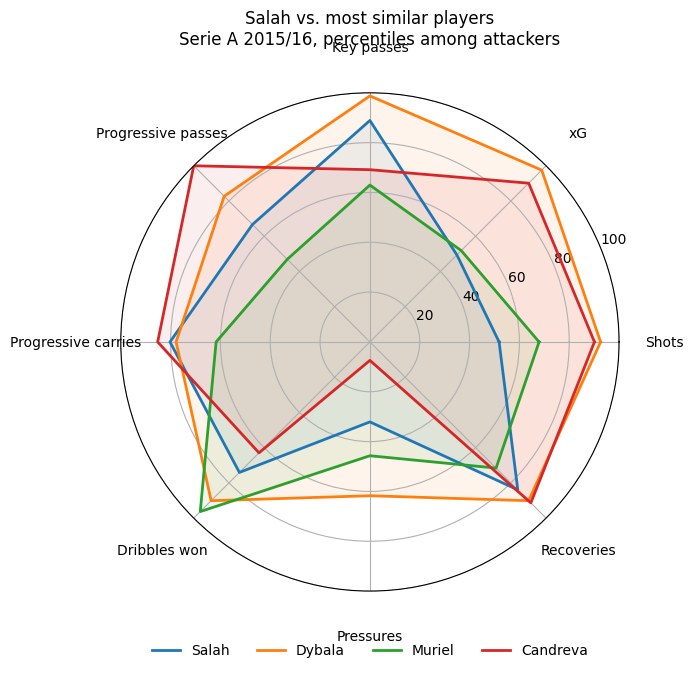

1000 ['Politano', 'Herrera', 'Torre', 'Dybala', 'Fruto'] [0.614, 0.613, 0.57, 0.536, 0.48]
1500 ['Dybala', 'Fruto', 'Candreva', 'Diao', 'Borriello'] [0.536, 0.48, 0.466, 0.381, 0.362]
2000 ['Dybala', 'Candreva', 'Insigne', 'Giaccherini', 'Perotti'] [0.536, 0.466, 0.325, 0.27, 0.267]
                                                team              position  \
player                                                                       
Matteo Politano                             Sassuolo            Right Wing   
Cristian Tello Herrera                    Fiorentina            Right Wing   
Jesús Joaquín Fernández Sáez de la Torre       Genoa            Right Wing   
Paulo Bruno Exequiel Dybala                 Juventus  Right Center Forward   
Luis Fernando Muriel Fruto                 Sampdoria        Center Forward   

                                            mins  similarity  
player                                                        
Matteo Politano                           1

In [6]:
# главный результат
res = similar_players("Mohamed Salah", top=5, min_mins=1500)
print(res)

# радар для первой тройки
names = ["Mohamed Salah"] + res.index[:3].tolist()
radar(names, "Salah vs. most similar players\nSerie A 2015/16, percentiles among attackers")

# проверка устойчивости к порогу минут
for m in (1000, 1500, 2000):
    r = similar_players("Mohamed Salah", top=5, min_mins=m)
    print(m, list(r.index.str.split().str[-1]), r.similarity.tolist())

# кандидаты с малой выборкой (900+ минут)
print(similar_players("Mohamed Salah", top=5, min_mins=900))